# Ingeven van het HSA model
De stappen zijn grotendeels overgenomen van een Ribasim Delwaq [voorbeeld](https://ribasim.org/guide/delwaq.html). Voor verdere informatie kan je de [Ribasim documentatie](https://ribasim.org/concept/concept.html) raadplegen. Deze workflow is een voorbeeld om:

1. De HSA Ribasim schematisatie in te laden en weer te geven
3. Ribasim berekening uitvoeren
4. Genereren van een Delwaq schematisatie op basis van het Ribasim model
4. Delwaq berekeningen uitvoeren
5. Fracties van tracers per basins visualiseren

Om Delwaq invoerbestanden te genereren is een doorgerekend Ribasim model (meestal met `results` map) nodig. Ideaal heeft de Ribasim schematisatie ook enkele stoffen gedefinieerd en initiële concentraties.  

### Importeren van de benodigde libraries
De meeste packages spreken voor zich, deze workflow bevat naast standaard packages ook extra functionaliteit vanuit `ribasim_tools`. Alle packages zouden al binnen de huidige .pixi omgeving geïnstalleerd moeten zijn.

In [1]:
import shutil

import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import display
from ribasim import Model
from ribasim.delwaq import add_tracer, generate, parse, plot_fraction

from ribasim_tools import run_delwaq, run_ribasim, settings

### Downloaden van het Basic ribasim model vanuit de Ribasim GitHub repository
We nemen hier het HSA model als voorbeeld, als je een ander Ribasim model wilt inladen: verander het `toml_path` om een ander Ribasim model in te lezen. Ook kan je het `.env`-bestand aanpassen waarin dezelfde verwijzing staat naar de padnaam van het Ribasim model. Het `.env`-bestand is een [tekst bestand](https://www.geeksforgeeks.org/python/how-to-create-and-use-env-files-in-python/) waarin settings naar ribasim en dimr .exe's kunnen worden opgegeven. 

In [2]:
toml_path = settings.data_dir.joinpath("hsa_model", "ribasim.toml")
assert toml_path.exists()

### Inlezen en tonen van het HSA model
Het HSA model heeft nog geen concentraties. We gaan hier enkele toevoegen voordat we ze gebruiken voor de Ribasim en Delwaq input bestanden.

c:\GitHub\ribasim_delwaq_aam\.pixi\envs\default\Lib\site-packages\ribasim\migrations.py:158: UserWarning: Migrating outdated Basin / profile table.
  warnings.warn("Migrating outdated Basin / profile table.", UserWarning)
c:\GitHub\ribasim_delwaq_aam\.pixi\envs\default\Lib\site-packages\ribasim\migrations.py:72: UserWarning: Migrating outdated Basin / static table.
  warnings.warn("Migrating outdated Basin / static table.", UserWarning)


Basin / concentration_state
None

Basin / concentration
None

FlowBoundary / concentration
None

LevelBoundary / concentration
None

,node_id,level,area,meta_levels,meta_rep_node_wl_id,meta_globalid,storage
fid,,,,,,,
0,10000001,27.152000,324.819563,OLO_1DRTC_bedlevel_summer_winter,1370.0,None,NaN
1,10000001,27.170034,463.763647,OLO_1DRTC_0_01MA_zomer,1370.0,None,NaN
2,10000001,27.170043,463.763648,OLO_1DRTC_0_01MA_winter,1370.0,None,NaN
3,10000001,27.178033,495.398867,OLO_1DRTC_0_02MA_zomer,1370.0,None,NaN
4,10000001,27.178042,495.398868,OLO_1DRTC_0_02MA_winter,1370.0,None,NaN
...,...,...,...,...,...,...,...
56236,50000145,30.375000,106567.000000,None,NaN,Peilgebied_DeurnsePeel_globalid_6,NaN
56237,50000145,30.425000,106567.250000,None,NaN,Peilgebied_DeurnsePeel_globalid_6,NaN
56238,50000145,30.475000,106567.750000,None,NaN,Peilgebied_DeurnsePeel_globalid_6,NaN


<Axes: >

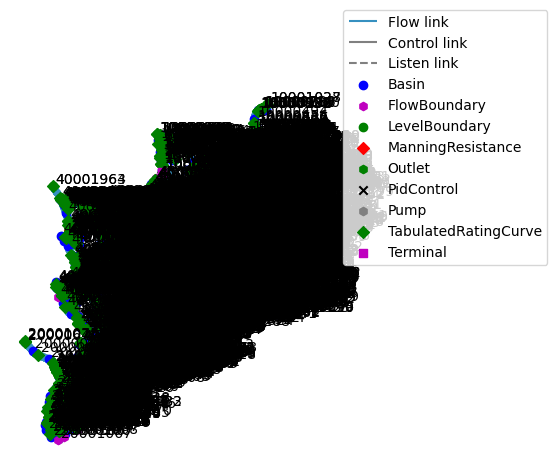

In [3]:
model = Model.read(toml_path)
display(model.basin.concentration_state)  # basin initial state
display(model.basin.concentration)  # basin boundaries
display(model.flow_boundary.concentration)  # flow boundaries
display(model.level_boundary.concentration)  # level boundaries
display(model.basin.profile)
model.plot()  # for later comparison

### Toevoegen van twee fictieve tracers Foo and Bar aan basins
Hier voegen we 2 tracers toe, aan 2 test basins, en geven ze een label. (Dit crasht nog omdat de kolommen er nog niet in zitten(?))

In [5]:
# add_tracer(model, 40000045, "Foo") # TODO: Value error, Unrecognized column 'concentration'.
# add_tracer(model, 30000276, "Bar") # TODO: Value error, Unrecognized column 'concentration'.
display(model.basin.concentration_state)  # basin initial state
display(model.basin.concentration)  # basin boundaries

Basin / concentration_state
None

Basin / concentration
None

### Eventuele resultaten uit een eerdere run verwijderen en het model opslaan op een nieuwe locatie
Het model wordt hier met ribasim.exe uitgevoerd. Mocht het crashen op het niet kunnen vinden van Ribasim dan kan je het pad naar Ribasim aanpassen in het `.env` bestand in de hoofd map.

In [ ]:
toml_path = settings.data_dir.joinpath("hsa_model") / model.filepath.name
shutil.rmtree(toml_path.parent, ignore_errors=True)
model.write(toml_path)
specs = run_ribasim(toml_path, settings.ribasim_exe)
assert specs.exit_code == 0

┌ Warning: The Ribasim version in the TOML config file does not match the
│ used Ribasim CLI version.
│   config.ribasim_version = "2025.3.0"
│   cli.ribasim_version = "2025.5.0"
└ @ Ribasim D:\buildAgent\work\ecd2b8f9b25b1609\ribasim\core\src\logging.jl:44
┌ Info: Starting a Ribasim simulation.
│   toml_path = "c:/GitHub/ribasim_delwaq_aam/data/hsa_model/ribasim.toml"
│   cli.ribasim_version = "2025.5.0"
│   starttime = 2005-01-01T00:00:00
│   endtime = 2006-01-01T00:00:00
└   threads = 1


### Genereren van het delwaq netwerk op basis van het Ribasim model
Met het pad naar een volledig doorgerekend Ribasim model kunnen we een Delwaq schematisatie opzetten. `generate` heeft een pad naar een (Ribasim) .toml-bestand nodig, of een `Model` object, en een pad naar een output map. De default waarde slaat de Delwaq input bestanden in een aparte `delwaq` map naast het .toml-bestand.

In [ ]:
output_path = model.filepath.parent.joinpath("delwaq")
graph, substances = generate(toml_path, output_path)
list(output_path.iterdir())
list(substances)

f:\Extern\Ribasim_Delwaq\GitHub\ribasim_delwaq_aam\.pixi\envs\default\Lib\site-packages\ribasim\delwaq\generate.py:410: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  volumes["riba_node_id"] = volumes["node_id"]


['UserDemand',
 'LevelBoundary',
 'Cl',
 'Bar',
 'Terminal',
 'Foo',
 'Precipitation',
 'Drainage',
 'Initial',
 'Tracer',
 'Continuity',
 'FlowBoundary']

## Delwaq en Ribasim schematisaties plotten

Hieronder worden de node ID's van de verschillende schematisatie getoond. Merk op dat elke basin in Ribasim wordt opgesplitst in 3 aparte bakjes. Door middel van de verschillende bakjes kan Delwaq de schematisatie opbouwen en er eigen node ID's van maken. De delwaq node ID's worden weer omgezet naar Ribasim ID's bij het inladen.

Text(0.5, 0.98, 'Delwaq network')

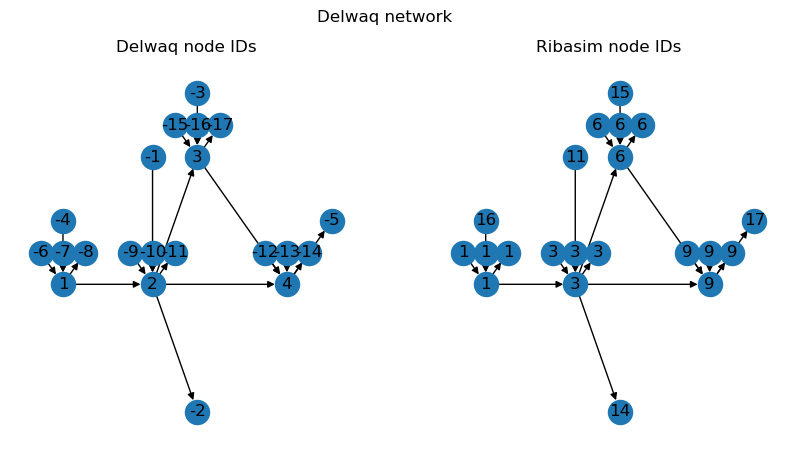

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
nx.draw(
    graph,
    pos={k: v["pos"] for k, v in graph.nodes(data=True)},
    with_labels=True,
    labels={k: k for k, v in graph.nodes(data=True)},
    ax=ax[0],
)
ax[0].set_title("Delwaq node IDs")
nx.draw(
    graph,
    pos={k: v["pos"] for k, v in graph.nodes(data=True)},
    with_labels=True,
    labels={k: v["id"] for k, v in graph.nodes(data=True)},
    ax=ax[1],
)
ax[1].set_title("Ribasim node IDs")
fig.suptitle("Delwaq network")

### Runnen van Delwaq met de DHydro DIMR
Onderstaande code runt de Delwaq input bestanden. We gebruiken hiervoor de D-Hydro DeltaShell dimr in plaats van de delwaq executable omdat deze betrouwbaarder is.

In [ ]:
from pathlib import Path

dimr_config = toml_path.parent.joinpath("delwaq", "dimr_config.xml")
print(dimr_config)
settings.run_dimr_bat = Path(
    r"c:\Program Files\Deltares\D-HYDRO Suite 2025.02 1D2D\plugins\DeltaShell.Dimr\kernels\x64\bin\run_dimr.bat"
)
specs = run_delwaq(dimr_config=dimr_config, run_dimr_bat=settings.run_dimr_bat)
assert specs.exit_code == 0

c:\GitHub\ribasim_delwaq_aam\data\basic_delwaq\delwaq\dimr_config.xml
Configfile:C:/GitHub/ribasim_delwaq_aam/data/basic_delwaq/delwaq/dimr_config.xml
OMP_NUM_THREADS is 16
Working directory: C:\GitHub\ribasim_delwaq_aam\data\basic_delwaq\delwaq
D3D_HOME         : C:\Program Files\Deltares\D-HYDRO Suite 2025.02 1D2D\plugins\DeltaShell.Dimr\kernels\x64\bin\..
executing: "C:\Program Files\Deltares\D-HYDRO Suite 2025.02 1D2D\plugins\DeltaShell.Dimr\kernels\x64\bin\..\bin\dimr.exe"  C:/GitHub/ribasim_delwaq_aam/data/basic_delwaq/delwaq/dimr_config.xml
Dimr [2025-10-15 13:04:37.896] #0 >> Deltares, DIMR_EXE Version 2.00.ea219e2faacbd73a3674d78bf0408f485bfc1242, Apr 25 2025, 12:49:07
Dimr [2025-10-15 13:04:38.169] #0 >> Deltares, DIMR_LIB Version 1.02.ea219e2faacbd73a3674d78bf0408f485bfc1242, Apr 25 2025, 12:48:44
Dimr [2025-10-15 13:04:38.950] #0 >> 
Dimr [2025-10-15 13:04:38.950] #0 >> Version Information of Components
Dimr [2025-10-15 13:04:38.950] #0 >> =================================


### Inlezen van de Delwaq resultaten in het Ribasim model en plotten van de concentraties van de twee tracers
Hieronder een voorbeeld om de fracties te plotten van een van de basins.

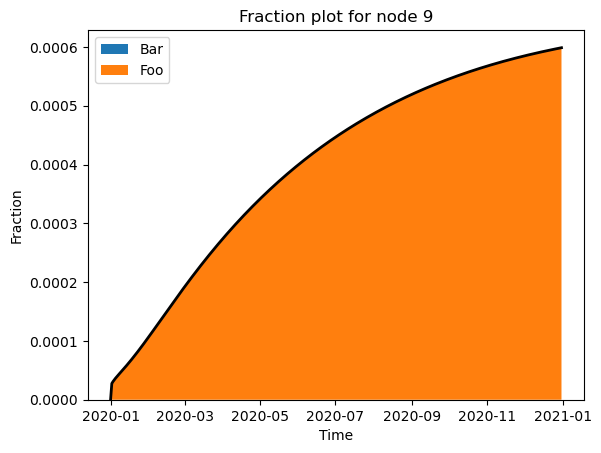

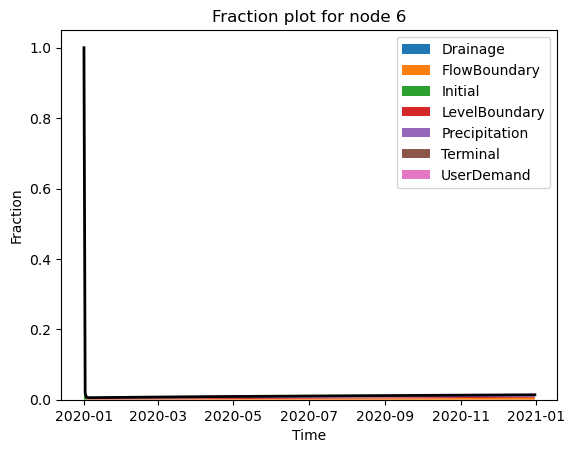

In [ ]:
nmodel = parse(toml_path, graph, substances, output_folder=output_path)

# plot_fraction(nmodel, 40000045, ["Foo", "Bar"])
# plot_fraction(nmodel, 30000276)